# Bayesian Optimisation Analysis â€” TraderCustom Parameter Search

This notebook analyses the GP-based Bayesian optimisation run over the three-dimensional parameter space of `TraderCustom`:

| Parameter | Symbol | Search range |
|---|---|---|
| Learning rate | Î² | [0.001, 0.30] |
| Position limit | L | [20, 800] |
| Volatility threshold | Î¸ | [3.0, 15.0] |

**Objective:** maximise mean MtM profit across 5 trials Ã— 4 market conditions.  
**Surrogate:** Gaussian Process with MatÃ©rn-5/2 kernel + nugget.  
**Acquisition:** Expected Improvement (EI), Î¾ = 0.01.  
**Budget:** 20 random initialisation points + 80 GP-guided iterations (100 total).

Re-run this notebook at any point â€” it reads from the live checkpoint file and adapts to however many iterations have completed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# â”€â”€ Academic publication style (matching bse_publication_figures_notex.ipynb) â”€â”€
plt.rcParams.update({
    'text.usetex':        False,
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif'],
    'axes.labelsize':     18,
    'font.size':          11,
    'legend.fontsize':    9,
    'xtick.labelsize':    14,
    'ytick.labelsize':    14,
    'axes.titlesize':     11,
    'figure.dpi':         300,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.5,
})

# â”€â”€ Load checkpoint â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CKPT_PATH  = 'data/bayesian_search_log.csv'
SAVE_DIR   = 'figures'   # change to 'figures/' once simulation phase is done

df = pd.read_csv(CKPT_PATH)
df.columns = df.columns.str.strip()

N_INIT = 20   # number of random initialisation points
df['phase'] = np.where(df['iteration'] <= N_INIT, 'Initialisation', 'GP-guided')
df['running_best'] = df['mean_profit'].cummax()

# Parameter bounds
BOUNDS = {
    'beta':                 (0.001, 0.30),
    'position_limit':       (20,    800),
    'volatility_threshold': (3.0,   15.0),
}
PARAM_LABELS = {
    'beta':                 r'Learning rate $\alpha$',
    'position_limit':       r'Position limit $L$',
    'volatility_threshold': r'Volatility threshold $\theta$',
}

# Colour: dark for initialisation, orange for GP-guided
PHASE_COLORS = {'Initialisation': '#1a3a5c', 'GP-guided': '#c0392b'}

print(f'Checkpoint loaded: {len(df)} iterations')
print(f'  Phase split: {N_INIT} init + {max(0, len(df)-N_INIT)} GP-guided')
print(f'  Best profit: {df["mean_profit"].max():.2f}  (iter {df["mean_profit"].idxmax()+1})')
print(f'  Best params: Î±={df.loc[df["mean_profit"].idxmax(), "beta"]:.4f}, '
      f'L={df.loc[df["mean_profit"].idxmax(), "position_limit"]:.0f}, '
      f'Î¸={df.loc[df["mean_profit"].idxmax(), "volatility_threshold"]:.2f}')

Checkpoint loaded: 100 iterations
  Phase split: 20 init + 80 GP-guided
  Best profit: 3776.48  (iter 91)
  Best params: Î±=0.0452, L=294, Î¸=14.99


In [8]:


# Panel B: 3D parameter space
fig = plt.figure(figsize=(10, 8), dpi = 1000)
ax3d = fig.add_subplot(111, projection='3d')
sc = ax3d.scatter(
    df['beta'], df['volatility_threshold'], df['position_limit'],
    c=df['iteration'], cmap='viridis', s=45, alpha=0.82
)
best = df.loc[df['mean_profit'].idxmax()]
ax3d.scatter(best['beta'], best['volatility_threshold'], best['position_limit'],
             color='red', s=300, marker='*', zorder=5)
ax3d.set_xlabel(r'$\alpha$', size=25)
ax3d.set_ylabel(r'$\sigma_{v}$', size=25)
ax3d.set_zlabel(r'$L$', size=25)
ax3d.set_ylim(6,15)
ax3d.set_title('Parameter Space Explored by the GP', size=20,
                 fontweight='bold', pad=10)
plt.colorbar(sc, ax=ax3d, label='Iteration', shrink=0.6, pad=0.1)
fig.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()

---
## Figure 3 â€” Marginal Effects of Each Parameter on Profit

Each panel shows profit as a function of one parameter (all values pooled, other two parameters ignored). The rolling mean (window = 10) highlights the trend. Vertical dashed lines mark the search boundary.

**What to look for:** A clear peak within the search range â†’ parameter is well-identified. Monotone increase/decrease to the boundary â†’ the optimum likely lies outside the range. Flat â†’ parameter is not informative.

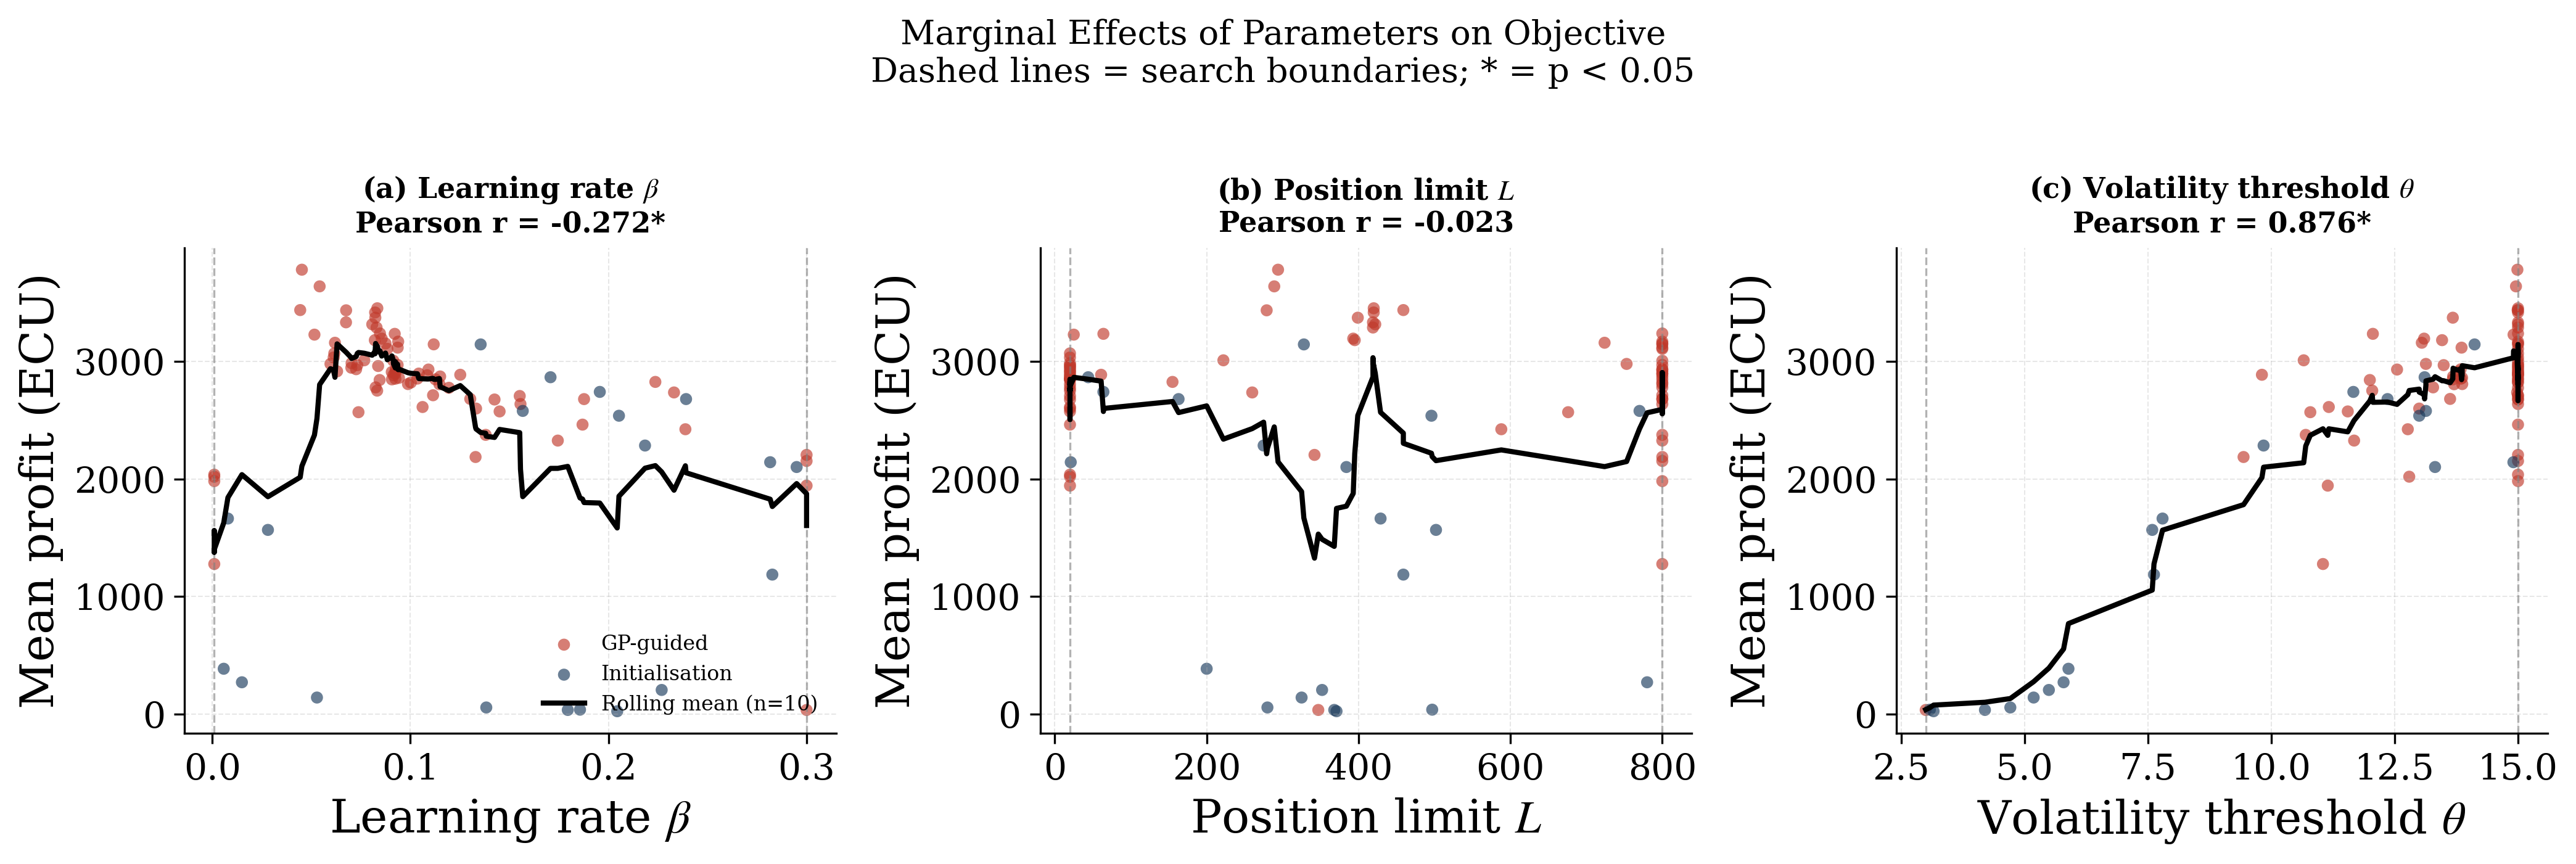

In [96]:
PARAMS = ['beta', 'position_limit', 'volatility_threshold']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, param in zip(axes, PARAMS):
    x = df[param].values
    y = df['mean_profit'].values

    # scatter, coloured by phase
    for phase, grp in df.groupby('phase'):
        ax.scatter(grp[param], grp['mean_profit'],
                   color=PHASE_COLORS[phase], s=22, alpha=0.65,
                   label=phase, edgecolors='none')

    # sorted rolling mean
    sorted_idx = np.argsort(x)
    xs, ys = x[sorted_idx], y[sorted_idx]
    if len(xs) >= 10:
        roll = pd.Series(ys).rolling(window=10, center=True, min_periods=5).mean()
        ax.plot(xs, roll.values, color='black', linewidth=2, zorder=5,
                label='Rolling mean (n=10)')

    # boundaries
    for bnd in BOUNDS[param]:
        ax.axvline(bnd, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)

    # correlation
    r, p = stats.pearsonr(x, y)
    sig = '*' if p < 0.05 else ''
    ax.set_xlabel(PARAM_LABELS[param])
    ax.set_ylabel('Mean profit (ECU)')
    ax.set_title(f'({chr(97+PARAMS.index(param))}) {PARAM_LABELS[param]}\n'
                 f'Pearson r = {r:.3f}{sig}')

axes[0].legend(fontsize=8, loc='lower right')

fig.suptitle('Marginal Effects of Parameters on Objective\n'
             'Dashed lines = search boundaries; * = p < 0.05', y=1.03)
plt.tight_layout()

plt.show()


---
## Figure 4 â€” Reconstructed GP Surrogate Surface

A Gaussian Process is re-fitted to the checkpoint data using a MatÃ©rn-5/2 kernel (matching the acquisition GP) and used to visualise the predicted profit landscape.

**Left:** GP mean prediction over Î² Ã— L (with Î¸ fixed at 15.0, the near-optimal value). Actual observations overlaid.  
**Right:** GP predictive standard deviation (epistemic uncertainty). High uncertainty = sparse data; low = confident prediction.

**What to look for:** The ridge / peak in the mean surface â€” this is what the GP used to direct sampling. The uncertainty map reveals which regions remain unexplored.

GP fitted. Optimised kernel: 1.81**2 * Matern(length_scale=[2.67, 1.43, 3.42], nu=2.5) + WhiteKernel(noise_level=0.0145)


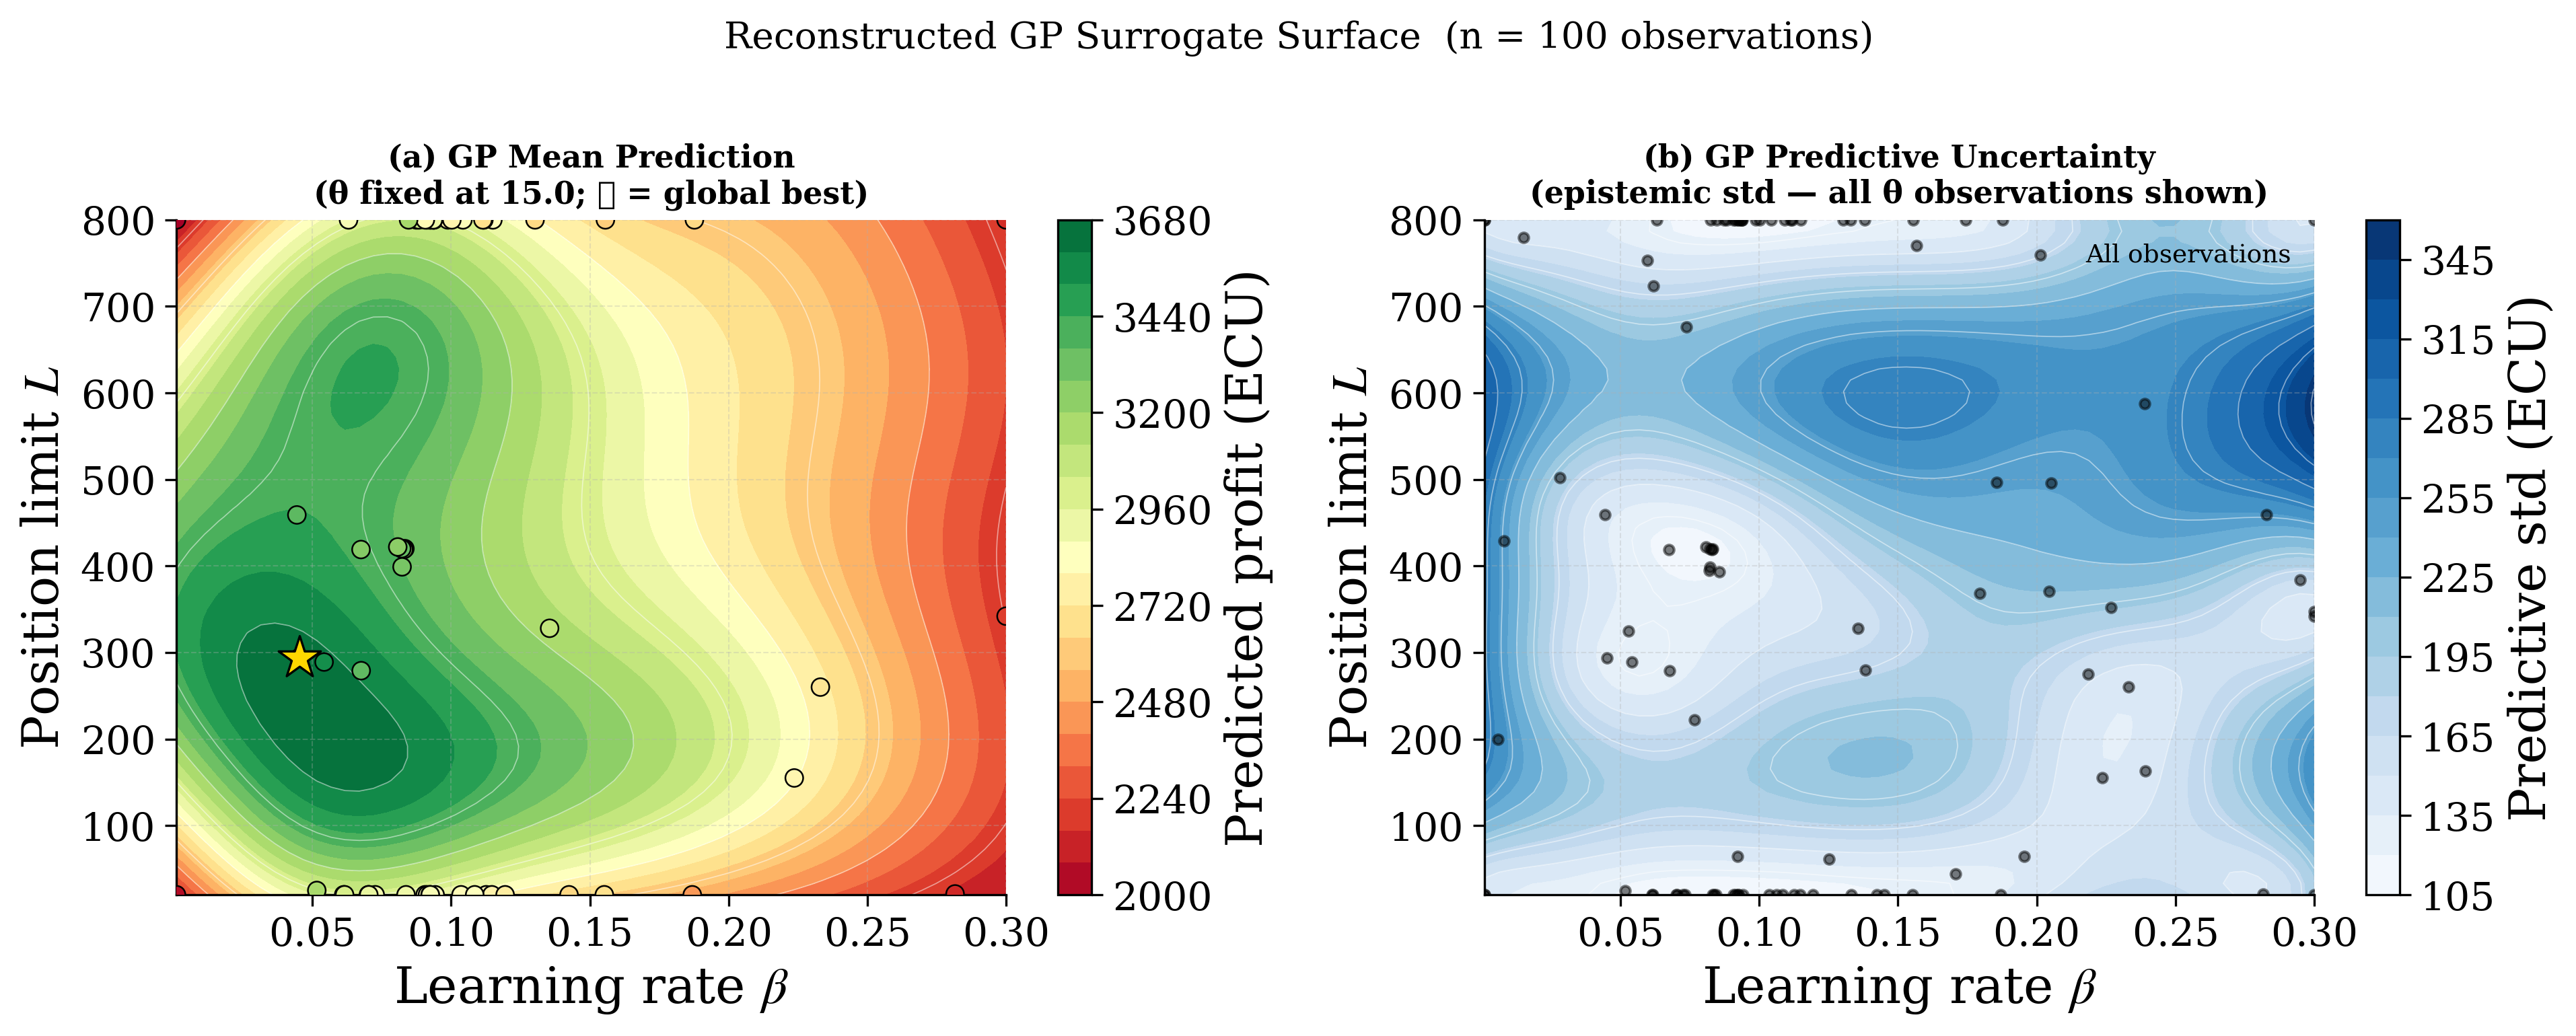

Figure 4 saved â†’ BO_gp_surface.png


In [97]:
# â”€â”€ Fit GP to checkpoint data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
X_raw = df[['beta', 'position_limit', 'volatility_threshold']].values
y_raw = df['mean_profit'].values

scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X_raw)
y_mean, y_std = y_raw.mean(), y_raw.std()
y_scaled = (y_raw - y_mean) / y_std

kernel = ConstantKernel(1.0) * Matern(nu=2.5, length_scale=np.ones(3)) + WhiteKernel(noise_level=0.1)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                               normalize_y=False, random_state=42)
gp.fit(X_scaled, y_scaled)
print(f'GP fitted. Optimised kernel: {gp.kernel_}')

# â”€â”€ Predict over Î² Ã— L grid (Î¸ fixed at 15.0) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N_GRID = 60
beta_grid = np.linspace(BOUNDS['beta'][0], BOUNDS['beta'][1], N_GRID)
pos_grid  = np.linspace(BOUNDS['position_limit'][0], BOUNDS['position_limit'][1], N_GRID)
BB, PP    = np.meshgrid(beta_grid, pos_grid)
theta_fix = 15.0

grid_pts  = np.column_stack([BB.ravel(), PP.ravel(),
                              np.full(N_GRID**2, theta_fix)])
grid_sc   = scaler_x.transform(grid_pts)
mu_sc, sigma_sc = gp.predict(grid_sc, return_std=True)
mu    = mu_sc    * y_std + y_mean
sigma = sigma_sc * y_std
MU    = mu.reshape(N_GRID, N_GRID)
SIGMA = sigma.reshape(N_GRID, N_GRID)

# â”€â”€ Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: mean
ax = axes[0]
im = ax.contourf(BB, PP, MU, levels=20, cmap='RdYlGn')
ax.contour(BB, PP, MU, levels=10, colors='white', linewidths=0.4, alpha=0.5)
plt.colorbar(im, ax=ax, label='Predicted profit (ECU)')

# Overlay observations (Î¸ near 15 Â± 1)
mask_theta = np.abs(df['volatility_threshold'] - theta_fix) <= 1.5
sc = ax.scatter(df.loc[mask_theta, 'beta'],
                df.loc[mask_theta, 'position_limit'],
                c=df.loc[mask_theta, 'mean_profit'],
                cmap='RdYlGn', s=40, edgecolors='black', linewidths=0.6,
                zorder=5)
ax.scatter(df.loc[best_idx, 'beta'], df.loc[best_idx, 'position_limit'],
           marker='*', s=250, color='gold', edgecolors='black',
           linewidths=0.8, zorder=6)
ax.set_xlabel(r'Learning rate $\beta$')
ax.set_ylabel(r'Position limit $L$')
ax.set_title(f'(a) GP Mean Prediction\n(Î¸ fixed at {theta_fix}; â˜… = global best)')

# Panel B: uncertainty
ax2 = axes[1]
im2 = ax2.contourf(BB, PP, SIGMA, levels=20, cmap='Blues')
ax2.contour(BB, PP, SIGMA, levels=10, colors='white', linewidths=0.4, alpha=0.5)
plt.colorbar(im2, ax=ax2, label='Predictive std (ECU)')
ax2.scatter(df['beta'], df['position_limit'],
            color='black', s=12, alpha=0.5, zorder=5, label='All observations')
ax2.set_xlabel(r'Learning rate $\beta$')
ax2.set_ylabel(r'Position limit $L$')
ax2.set_title('(b) GP Predictive Uncertainty\n(epistemic std â€” all Î¸ observations shown)')
ax2.legend(fontsize=9)

fig.suptitle(f'Reconstructed GP Surrogate Surface  (n = {len(df)} observations)',
             y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/fig2_gp_parameter_space.png')
plt.show()
print('Figure 4 saved â†’ figures/fig2_gp_parameter_space.png')

---
## Figure 5 â€” Parameter Collapsed Dimensions (Boundary Analysis)

A key finding is that `position_limit` and `volatility_threshold` show **boundary collapse**: after early exploration the GP repeatedly samples at the extremes of these parameters. This figure quantifies that collapse over time.

**Left:** Cumulative fraction of GP-guided iterations that landed within 5% of each parameter's boundary.  
**Right:** Running mean of each parameter over iterations, showing convergence to a fixed value.

**What to look for:** Flat running mean = converged parameter. Monotone drift to a boundary = the GP found no benefit to interior values.

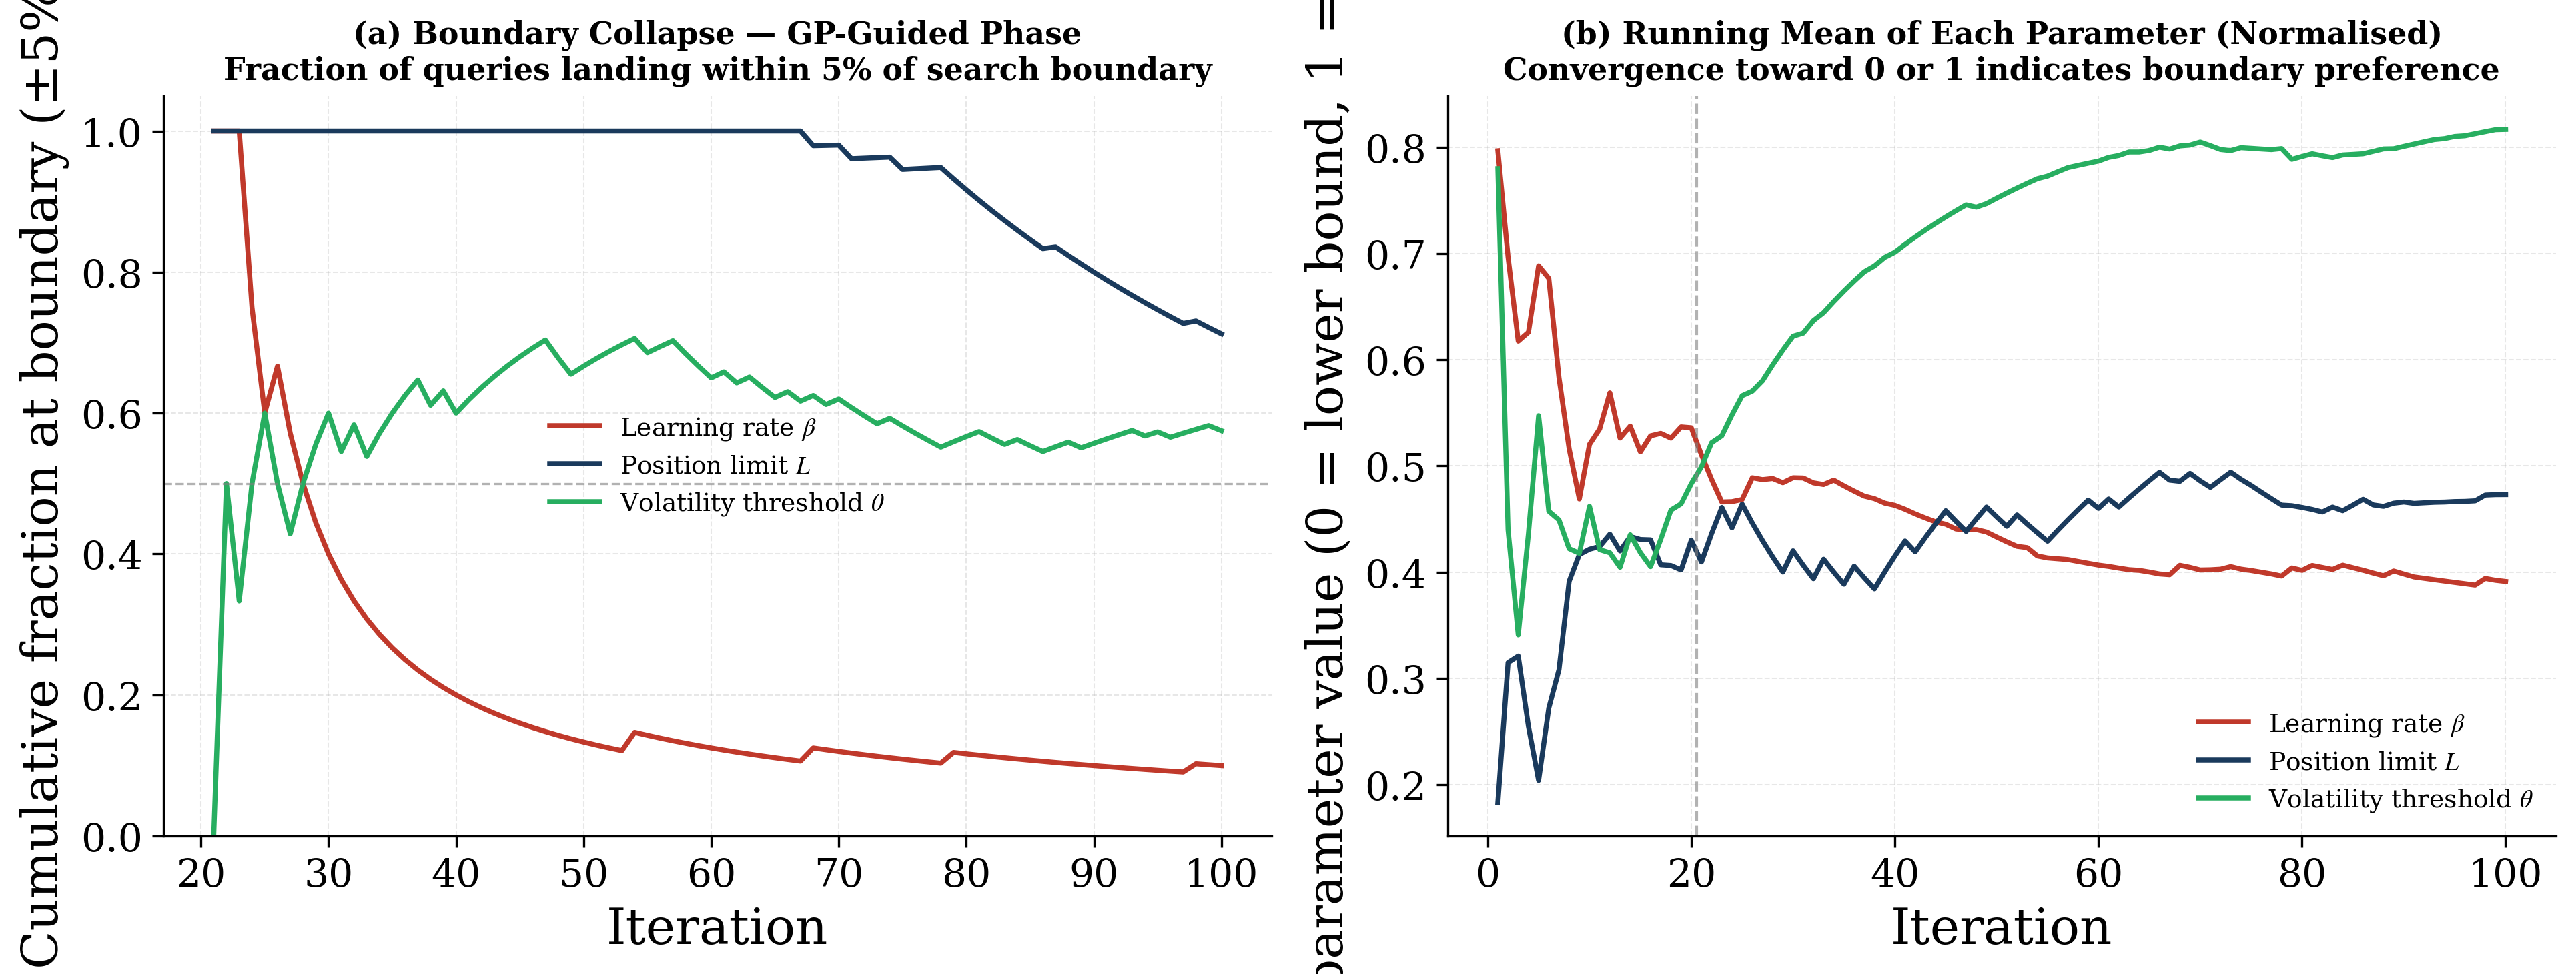

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: fraction near boundary over time (GP-guided only)
ax = axes[0]
gp_df = df[df['phase'] == 'GP-guided'].reset_index(drop=True)

PARAM_COLORS = {'beta': '#c0392b', 'position_limit': '#1a3a5c',
                'volatility_threshold': '#27ae60'}

for param in PARAMS:
    lo, hi = BOUNDS[param]
    tol = (hi - lo) * 0.05
    near_bnd = ((gp_df[param] <= lo + tol) | (gp_df[param] >= hi - tol)).astype(float)
    cum_frac  = near_bnd.cumsum() / (np.arange(len(near_bnd)) + 1)
    ax.plot(gp_df.index + N_INIT + 1, cum_frac,
            label=PARAM_LABELS[param], color=PARAM_COLORS[param], linewidth=1.8)

ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cumulative fraction at boundary (Â±5%)')
ax.set_title('(a) Boundary Collapse â€” GP-Guided Phase\n'
             'Fraction of queries landing within 5% of search boundary')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# Panel B: running mean of each parameter (normalised to [0,1])
ax2 = axes[1]
for param in PARAMS:
    lo, hi = BOUNDS[param]
    norm_vals  = (df[param] - lo) / (hi - lo)
    run_mean   = norm_vals.expanding().mean()
    ax2.plot(df['iteration'], run_mean,
             label=PARAM_LABELS[param], color=PARAM_COLORS[param], linewidth=1.8)

ax2.axvline(N_INIT + 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.6)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Normalised parameter value (0 = lower bound, 1 = upper bound)')
ax2.set_title('(b) Running Mean of Each Parameter (Normalised)\n'
             'Convergence toward 0 or 1 indicates boundary preference')
ax2.legend(fontsize=9)

plt.tight_layout()

plt.show()


---
## Figure 6 â€” Exploration vs Exploitation Balance

Expected Improvement (EI) drives a natural trade-off: early iterations explore uncertain regions; later iterations exploit the identified optimum. We proxy this balance by the **distance of each query from the current best-known point** in normalised parameter space.

- Large distance = exploration (querying new regions)
- Small distance = exploitation (refining near the best)

**What to look for:** A declining distance trend over the GP-guided phase indicates the algorithm is progressively tightening around the optimum.

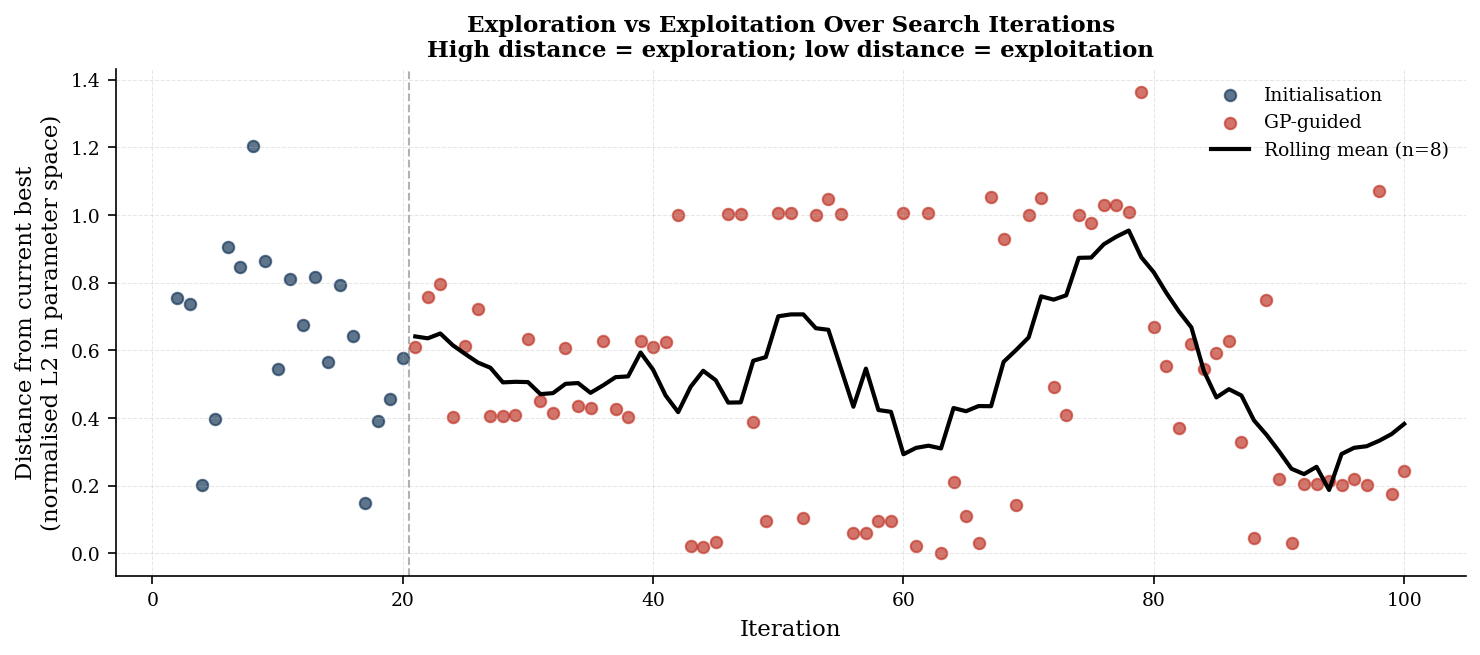

In [49]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Normalise parameter columns to [0, 1]
df_norm = df.copy()
for param in PARAMS:
    lo, hi = BOUNDS[param]
    df_norm[param] = (df[param] - lo) / (hi - lo)

# Distance of each point from the best-at-previous-step
dist = []
for i, row in df_norm.iterrows():
    if i == 0:
        dist.append(np.nan)
        continue
    prev_best_idx = df['mean_profit'].iloc[:i].idxmax()
    best_pt = df_norm.loc[prev_best_idx, PARAMS].values
    curr_pt = row[PARAMS].values
    dist.append(np.linalg.norm(curr_pt - best_pt))

df_norm['dist_from_best'] = dist

# Plot
init_mask = df_norm['phase'] == 'Initialisation'
gp_mask   = df_norm['phase'] == 'GP-guided'

ax.scatter(df_norm.loc[init_mask, 'iteration'], df_norm.loc[init_mask, 'dist_from_best'],
           color=PHASE_COLORS['Initialisation'], s=30, alpha=0.7, label='Initialisation')
ax.scatter(df_norm.loc[gp_mask,   'iteration'], df_norm.loc[gp_mask,   'dist_from_best'],
           color=PHASE_COLORS['GP-guided'],   s=30, alpha=0.7, label='GP-guided')

# Rolling mean (GP-guided only)
gp_df2 = df_norm[gp_mask].copy()
if len(gp_df2) >= 5:
    roll = gp_df2['dist_from_best'].rolling(window=8, min_periods=3, center=True).mean()
    ax.plot(gp_df2['iteration'], roll, color='black', linewidth=2,
            label='Rolling mean (n=8)')

ax.axvline(N_INIT + 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Iteration')
ax.set_ylabel('Distance from current best\n(normalised L2 in parameter space)')
ax.set_title('Exploration vs Exploitation Over Search Iterations\n'
             'High distance = exploration; low distance = exploitation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## Summary Table â€” Top-10 Configurations

Ranked by mean profit across the evaluation trials.

In [51]:
top10 = (df.sort_values('mean_profit', ascending=False)
           .head(10)
           [['iteration','beta','position_limit','volatility_threshold','mean_profit','phase']]
           .reset_index(drop=True))

print('=' * 75)
print('TOP-10 CONFIGURATIONS  â€”  Bayesian Optimisation v7')
print('=' * 75)
print(f"  {'Rank':<5}  {'Iter':<6}  {'Beta':>8}  {'Pos Lim':>8}  "
      f"{'Vol Thresh':>11}  {'Profit':>10}  {'Phase'}")
print('  ' + '-' * 68)
for rank, (_, row) in enumerate(top10.iterrows(), 1):
    print(f"  {rank:<5}  {int(row['iteration']):<6}  {row['beta']:>8.4f}  "
          f"{int(row['position_limit']):>8}  {row['volatility_threshold']:>11.2f}  "
          f"{row['mean_profit']:>10.2f}  {row['phase']}")
print()
top10

TOP-10 CONFIGURATIONS  â€”  Bayesian Optimisation v7
  Rank   Iter        Beta   Pos Lim   Vol Thresh      Profit  Phase
  --------------------------------------------------------------------
  1      91        0.0452       294        14.99     3776.48  GP-guided
  2      88        0.0542       289        14.96     3634.98  GP-guided
  3      92        0.0833       420        15.00     3449.00  GP-guided
  4      90        0.0444       459        14.99     3433.70  GP-guided
  5      80        0.0676       279        15.00     3431.64  GP-guided
  6      95        0.0822       420        15.00     3413.33  GP-guided
  7      94        0.0823       399        13.68     3368.95  GP-guided
  8      99        0.0675       419        15.00     3329.51  GP-guided
  9      97        0.0807       422        15.00     3312.68  GP-guided
  10     93        0.0829       419        15.00     3285.45  GP-guided



,iteration,beta,position_limit,volatility_threshold,mean_profit,phase
0,91,0.045223,294,14.987470,3776.4803,GP-guided
1,88,0.054194,289,14.958652,3634.9775,GP-guided
2,92,0.083317,420,15.000000,3448.9983,GP-guided
3,90,0.044385,459,14.992415,3433.7010,GP-guided
4,80,0.067564,279,15.000000,3431.6413,GP-guided
5,95,0.082193,420,15.000000,3413.3263,GP-guided
6,94,0.082303,399,13.679051,3368.9497,GP-guided
7,99,0.067502,419,15.000000,3329.5070,GP-guided
8,97,0.080745,422,15.000000,3312.6755,GP-guided
9,93,0.082926,419,15.000000,3285.4465,GP-guided


In [ ]:
# Inventory tracking for selected trader types across all market conditions
import os

INV_PATH = 'data/inventory_timeseries.csv'
INV_SAVE_DIR = 'data'
os.makedirs(INV_SAVE_DIR, exist_ok=True)

inv_df = pd.read_csv(INV_PATH)
inv_df.columns = inv_df.columns.str.strip()

selected_traders = ['ZIP', 'SHVR', 'PRSH']
inv_df = inv_df[inv_df['ttype'].isin(selected_traders)].copy()

for ttype in selected_traders:
    plot_df = inv_df[inv_df['ttype'] == ttype].sort_values(['condition','timestep'])
    fig, ax = plt.subplots(figsize=(13, 7))
    for condition, grp in plot_df.groupby('condition'):
        ax.plot(grp['timestep']*10, grp['mean_inv'], label=condition, linewidth=1.8)

    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Mean inventory', size=18)
    ax.set_title(f'Inventory evolution for {ttype}', size = 16)
    ax.set_xlim(plot_df['timestep'].min() * 10, plot_df['timestep'].max() * 10)
    ax.legend(title='Market condition', fontsize=20, title_fontsize=11,
              loc='upper left', bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    fname = os.path.join(INV_SAVE_DIR, f'inventory_{ttype}.png')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()


Saved: results_v7\inventory_mean_combined.png


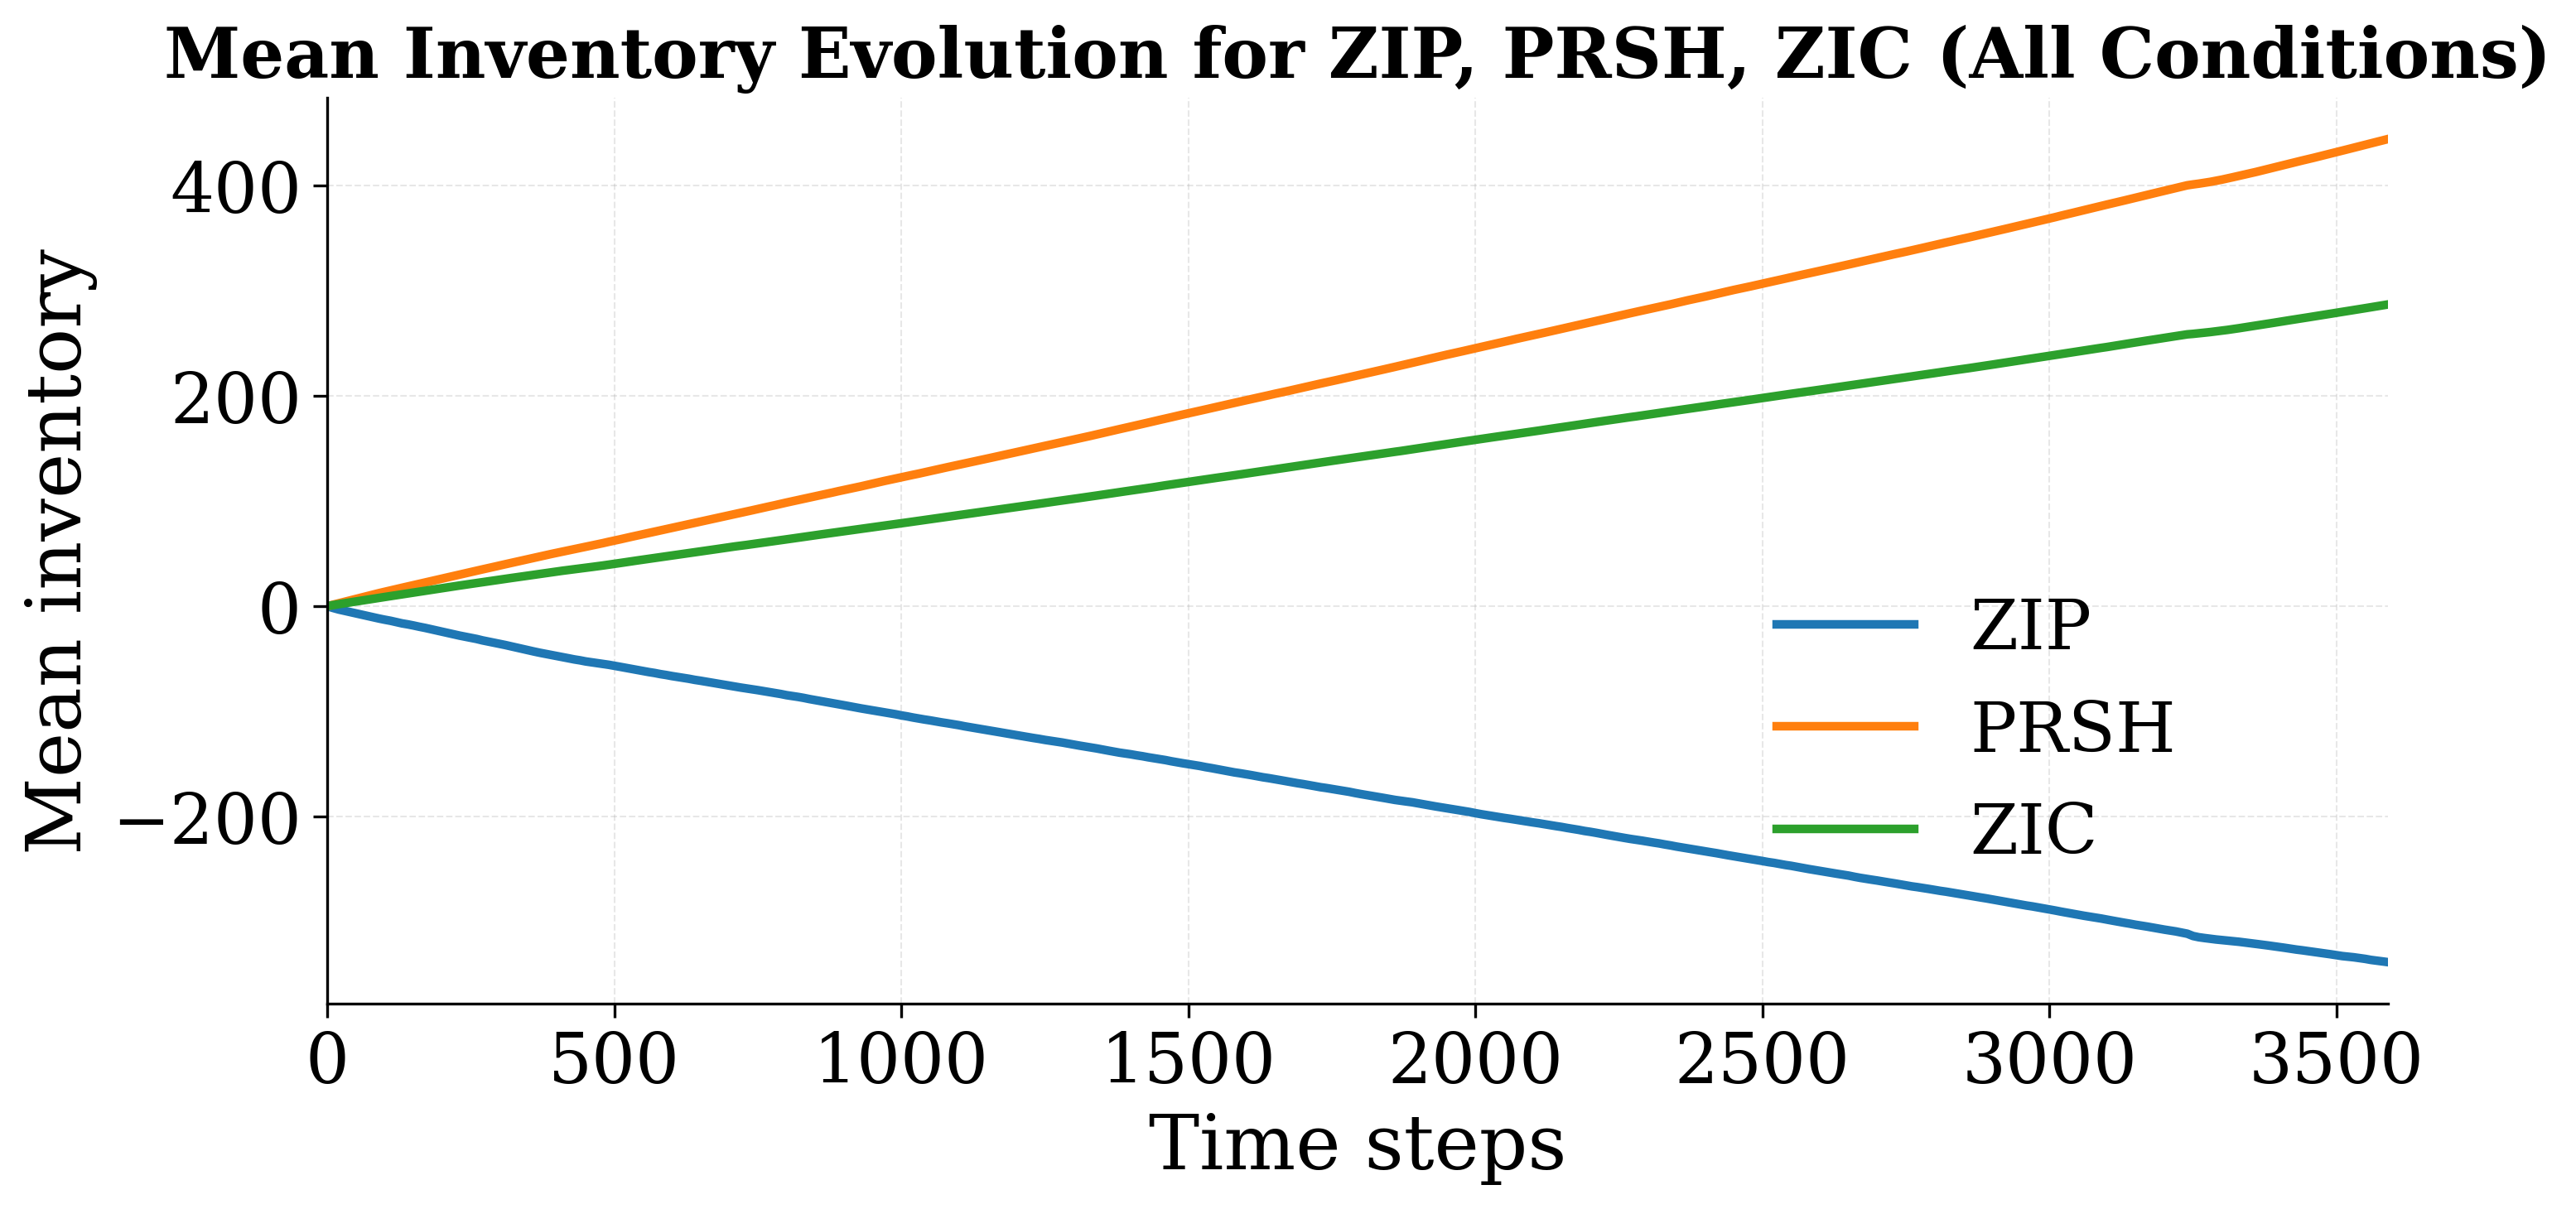

In [137]:
# Inventory tracking for the mean inventory per trader type across all conditions
import os

INV_PATH = 'data/inventory_timeseries.csv'
INV_SAVE_DIR = 'data'
os.makedirs(INV_SAVE_DIR, exist_ok=True)

BEST_PERCENT = None  # set to 20 for top 20% performing traders per type
SELECTED_TRADERS = ['ZIP', 'PRSH', 'ZIC']

inv_df = pd.read_csv(INV_PATH)
inv_df.columns = inv_df.columns.str.strip()
inv_df = inv_df[inv_df['ttype'].isin(SELECTED_TRADERS)].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for ttype in SELECTED_TRADERS:
    ttype_df = inv_df[inv_df['ttype'] == ttype].copy()
    if BEST_PERCENT is not None:
        trial_scores = (
            ttype_df.groupby('trial')['mean_inv']
                   .apply(lambda x: x.abs().mean())
                   .sort_values(ascending=False)
        )
        top_n = max(1, int(np.ceil(len(trial_scores) * BEST_PERCENT / 100)))
        top_trials = trial_scores.head(top_n).index
        ttype_df = ttype_df[ttype_df['trial'].isin(top_trials)].copy()

    plot_df = (
        ttype_df.groupby('timestep')['mean_inv']
              .mean()
              .reset_index()
    )

    ax.plot(plot_df['timestep']*10, plot_df['mean_inv'], linewidth=2.5, label=ttype)

ax.set_xlabel('Time steps', fontsize=22)
ax.set_ylabel('Mean inventory', fontsize=22)
title_suffix = '' if BEST_PERCENT is None else f' (top {BEST_PERCENT}% trials)'
ax.set_title(f'Mean Inventory Evolution for {", ".join(SELECTED_TRADERS)}{title_suffix} (All Conditions)', fontsize=20)
ax.set_xlim(plot_df['timestep'].min()*10, plot_df['timestep'].max()*10)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=20, loc='center', bbox_to_anchor=(0.80, 0.300))
plt.tight_layout()
fname = os.path.join(INV_SAVE_DIR, f'inventory_mean_combined.png' if BEST_PERCENT is None else f'inventory_mean_combined_top{BEST_PERCENT}pct.png')
fig.savefig(fname, dpi=300, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()